In [1]:
# This is where I will Analyze Rain/Snow
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
daily_ridership = pd.read_csv("../../data/01-interim/MTA_subway/MTA_Subway_Daily_Manhattan_Totals.csv")
# Outliers:
# Date: 2023-01-02, Ridership: 1062726, Day: Monday (-3.46σ)
# Date: 2023-01-16, Ridership: 1135997, Day: Monday (-3.18σ)
# Date: 2023-02-20, Ridership: 1189966, Day: Monday (-2.97σ)
# Date: 2023-05-29, Ridership: 1048880, Day: Monday (-3.51σ)
# Date: 2023-06-19, Ridership: 1407937, Day: Monday (-2.15σ)
# Date: 2023-07-03, Ridership: 1423957, Day: Monday (-2.09σ)
# Date: 2023-07-04, Ridership: 952323, Day: Tuesday (-3.87σ)
# Date: 2023-09-04, Ridership: 996208, Day: Monday (-3.71σ)
# Date: 2023-09-29, Ridership: 1364610, Day: Friday (-2.31σ)
# Date: 2023-11-23, Ridership: 941205, Day: Thursday (-3.92σ)
# Date: 2023-11-24, Ridership: 1398884, Day: Friday (-2.18σ)
# Date: 2023-12-25, Ridership: 757361, Day: Monday (-4.61σ)
# Date: 2023-10-28, Ridership: 1606262, Day: Saturday (+2.17σ)
# Date: 2023-12-02, Ridership: 1670874, Day: Saturday (+2.53σ)
# Date: 2023-12-09, Ridership: 1783307, Day: Saturday (+3.14σ)
# Date: 2023-12-16, Ridership: 1745770, Day: Saturday (+2.93σ)

Outliers = ['2023-01-02','2023-01-16','2023-02-20','2023-05-29','2023-06-19','2023-07-03','2023-07-04',
            '2023-09-04','2023-10-28','2023-11-23','2023-11-24','2023-12-02','2023-12-16','2023-12-25']

daily_ridership = daily_ridership[~daily_ridership['date'].isin(Outliers)]
daily_ridership.head()

,date,ridership
0,2023-01-01,1013185
2,2023-01-03,1734883
3,2023-01-04,1862526
4,2023-01-05,1865376
5,2023-01-06,1702969


In [3]:
daily_weather = pd.read_csv("../../data/01-interim/Weather/CLEANED_CentralPark_Weather2023.csv")
daily_weather.head()

,Station,Name,Latitude,Longitude,Date,Precipitation,Snow,Avg_Temp,Max_Temp,Min_Temp,Rain?,Snow?
0,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,2023-01-01,0.00,0.0,52.0,55.0,49.0,no,no
1,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,2023-01-02,0.02,0.0,52.5,56.0,49.0,yes,no
2,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,2023-01-03,0.42,0.0,52.5,58.0,47.0,yes,no
3,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,2023-01-04,0.02,0.0,57.5,66.0,49.0,yes,no
4,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,2023-01-05,0.01,0.0,47.0,50.0,44.0,yes,no


In [4]:
daily_weather = daily_weather.drop(['Station','Name','Latitude','Longitude','Avg_Temp','Max_Temp','Min_Temp'], axis = 1)
daily_weather.head()

,Date,Precipitation,Snow,Rain?,Snow?
0,2023-01-01,0.00,0.0,no,no
1,2023-01-02,0.02,0.0,yes,no
2,2023-01-03,0.42,0.0,yes,no
3,2023-01-04,0.02,0.0,yes,no
4,2023-01-05,0.01,0.0,yes,no


In [5]:
daily_ridership['date'] = pd.to_datetime(daily_ridership['date'])
daily_weather['Date'] = pd.to_datetime(daily_weather['Date'])

In [6]:
# 1. Normalize the column names for merging
# Your first dataframe has 'date' and the second has 'Date'
daily_ridership.rename(columns={'date': 'Date', 'ridership': 'Ridership'}, inplace=True)

# 2. Merge the dataframes on the Date column
# We use an 'inner' join to only correlate dates that exist in both datasets
daily_merged = pd.merge(daily_ridership, daily_weather, on='Date')

# 3. Ensure the columns are in the correct format (as specified)
daily_merged['Ridership'] = daily_merged['Ridership'].astype(int)
daily_merged['Precipitation'] = daily_merged['Precipitation'].astype(float)
daily_merged['Snow'] = daily_merged['Snow'].astype(float)

In [7]:
# .dt.dayofweek returns 0-6. 5 and 6 are Sat/Sun.
daily_merged['is_weekend'] = daily_merged['Date'].dt.dayofweek >= 5

# Create the two subsets
daily_merged_weekends = daily_merged[daily_merged['is_weekend']]
daily_merged_weekdays = daily_merged[~daily_merged['is_weekend']]

print(daily_merged_weekends.head())
print(daily_merged_weekdays.head())

daily_merged_weekends.Snow.value_counts()

         Date  Ridership  Precipitation  Snow Rain? Snow?  is_weekend
0  2023-01-01    1013185            0.0   0.0    no    no        True
5  2023-01-07    1176616            0.0   0.0    no    no        True
6  2023-01-08     885711            0.0   0.0    no    no        True
12 2023-01-14    1171928            0.0   0.0    no    no        True
13 2023-01-15     969151            0.0   0.0    no    no        True
        Date  Ridership  Precipitation  Snow Rain? Snow?  is_weekend
1 2023-01-03    1734883           0.42   0.0   yes    no       False
2 2023-01-04    1862526           0.02   0.0   yes    no       False
3 2023-01-05    1865376           0.01   0.0   yes    no       False
4 2023-01-06    1702969           0.27   0.0   yes    no       False
7 2023-01-09    1647407           0.01   0.0   yes    no       False


Snow
0.0    102
Name: count, dtype: int64

In [11]:
from scipy.stats import pearsonr

# Define the columns to keep things clean
cols = ['Ridership', 'Precipitation', 'Snow']

# We must drop NaNs because scipy's pearsonr cannot handle missing values natively
df_weekends = daily_merged_weekends[cols].dropna()
df_weekdays = daily_merged_weekdays[cols].dropna()

# Calculate the p-values using a lambda function
p_values_weekends = df_weekends.corr(method=lambda x, y: pearsonr(x, y)[1])
p_values_weekdays = df_weekdays.corr(method=lambda x, y: pearsonr(x, y)[1])

print("P-Values Matrix (Weekends):")
print(p_values_weekends)

print("\nP-Values Matrix (Weekdays):")
print(p_values_weekdays)

P-Values Matrix (Weekends):
               Ridership  Precipitation  Snow
Ridership        1.00000        0.15224   NaN
Precipitation    0.15224        1.00000   NaN
Snow                 NaN            NaN   1.0

P-Values Matrix (Weekdays):
                  Ridership  Precipitation      Snow
Ridership      1.000000e+00   2.566823e-07  0.147935
Precipitation  2.566823e-07   1.000000e+00  0.758106
Snow           1.479352e-01   7.581062e-01  1.000000


/tmp/ipykernel_15198/3622568612.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  p_values_weekends = df_weekends.corr(method=lambda x, y: pearsonr(x, y)[1])


Correlation Matrix (Weekends):
               Ridership  Precipitation  Snow
Ridership       1.000000      -0.142788   NaN
Precipitation  -0.142788       1.000000   NaN
Snow                 NaN            NaN   NaN
Correlation Matrix (Weekdays):
               Ridership  Precipitation      Snow
Ridership       1.000000      -0.319549 -0.091960
Precipitation  -0.319549       1.000000  0.019614
Snow           -0.091960       0.019614  1.000000


Text(0.5, 1.0, 'Correlation: Ridership (Weekdays) vs. Weather (Precipitation & Snow)')

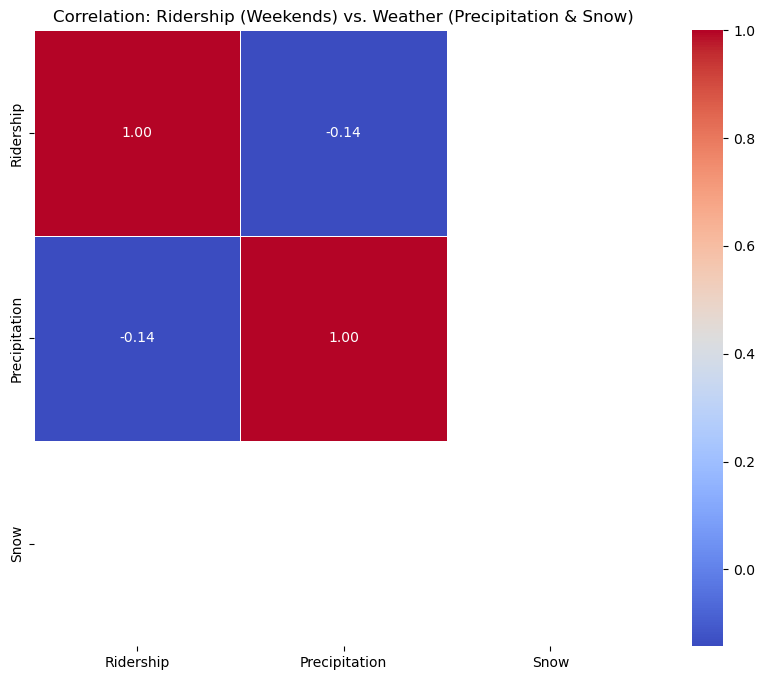

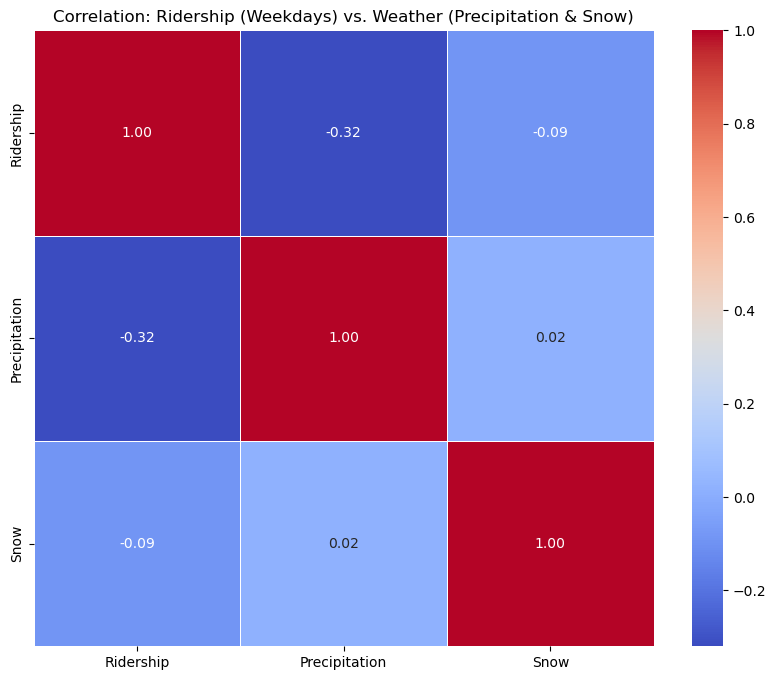

In [12]:
# 4. Calculate the correlation matrix
# This uses the Pearson correlation coefficient by default
correlation_matrix_weekends = daily_merged_weekends[['Ridership', 'Precipitation', 'Snow']].corr()
correlation_matrix_weekdays = daily_merged_weekdays[['Ridership', 'Precipitation', 'Snow']].corr()

print("Correlation Matrix (Weekends):")
print(correlation_matrix_weekends)

print("Correlation Matrix (Weekdays):")
print(correlation_matrix_weekdays)

# 5. Visualize the correlations with a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_weekends, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation: Ridership (Weekends) vs. Weather (Precipitation & Snow)')
#plt.savefig('ridership_weather_correlation.png')
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_weekdays, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation: Ridership (Weekdays) vs. Weather (Precipitation & Snow)')
#plt.savefig('ridership_weather_correlation.png')

Updated Correlation Matrix:
               Ridership  Precipitation      Snow  Rain_binary  Snow_binary
Ridership       1.000000      -0.181575  0.020805    -0.146880     0.041938
Precipitation  -0.181575       1.000000  0.011625     0.498035    -0.001136
Snow            0.020805       0.011625  1.000000     0.126729     0.858309
Rain_binary    -0.146880       0.498035  0.126729     1.000000     0.147649
Snow_binary     0.041938      -0.001136  0.858309     0.147649     1.000000


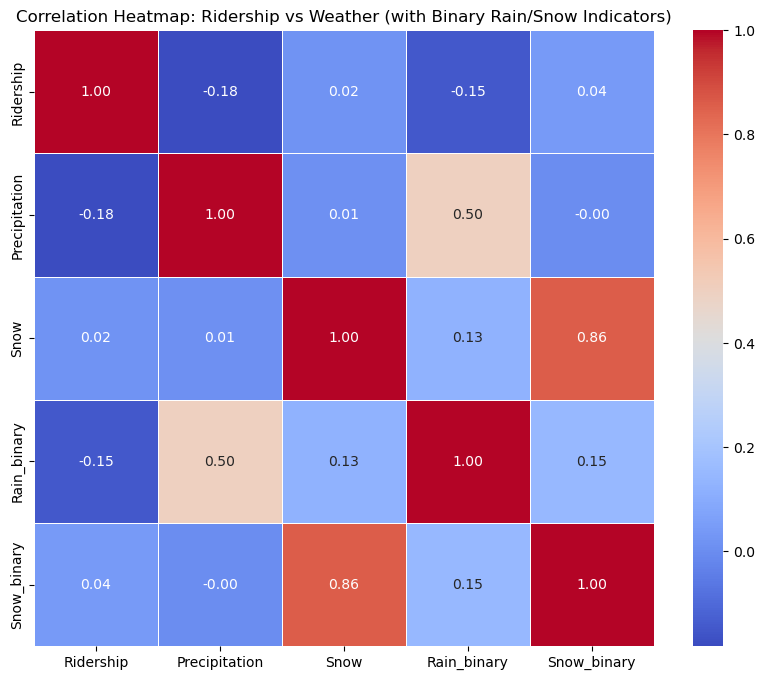

In [8]:
# 3. Convert 'yes'/'no' strings to 1/0 integers
# Assuming 'Rain' and 'Snow_string' are the names of the new string columns
# We'll create new columns for clarity, but you can overwrite if you prefer
daily_merged['Rain_binary'] = daily_merged['Rain?'].map({'yes': 1, 'no': 0})
daily_merged['Snow_binary'] = daily_merged['Snow?'].map({'yes': 1, 'no': 0})

# 4. Calculate correlation matrix including the new binary columns
# Note: Ensure you include all relevant column names in the list below
cols_to_correlate = [
    'Ridership', 
    'Precipitation', 
    'Snow',        # This is the original float/amount column
    'Rain_binary', # The new binary indicator
    'Snow_binary'  # The new binary indicator
]

correlation_matrix = daily_merged[cols_to_correlate].corr()

print("Updated Correlation Matrix:")
print(correlation_matrix)

# 5. Visualize the correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Ridership vs Weather (with Binary Rain/Snow Indicators)')
plt.savefig('correlation_with_binary_indicators.png')

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# 1. Prepare the features (X) and target (y)
# We include both the continuous amounts and the binary 'yes/no' indicators
X = daily_merged[['Precipitation', 'Snow']]
y = daily_merged['Ridership']

# 2. Scale the features
# This allows us to compare coefficients directly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Make predictions
y_pred = model.predict(X_test)

In [13]:
# Create a summary of the coefficients
coefficients = pd.DataFrame({
    'Feature': ['Precipitation', 'Snow'],
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("Standardized Coefficients:")
print(coefficients)

# Evaluate the model
print(f"\nR-squared Score: {r2_score(y_test, y_pred):.4f}")

Standardized Coefficients:
         Feature   Coefficient
1           Snow  17337.135000
0  Precipitation -67116.300504

R-squared Score: 0.0442


In [ ]:
# From this it appears the weather at Central Park has 
# very little impact on the overall ridership in Manhattan.
# The precipitation column does appear to have a more significant
# impact than snow, and they have inverse impacts on ridership.
# the positive impact of snow and negative impact of rain on
# ridership shows up in correlation and the linear regression.

In [14]:
# Convert to datetime if it isn't already
daily_merged['Date'] = pd.to_datetime(daily_merged['Date'])

# Get the day name (Monday, Tuesday, etc.)
daily_merged['Day_of_Week'] = daily_merged['Date'].dt.day_name()

# Get a binary indicator for weekends (Saturday/Sunday = 1, Weekdays = 0)
daily_merged['Is_Weekend'] = daily_merged['Date'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

In [17]:
# 1. One-hot encode the days
day_dummies = pd.get_dummies(daily_merged['Day_of_Week'], drop_first=True)

# 2. Combine with our weather data
X_final = pd.concat([
    daily_merged[['Precipitation', 'Snow']],
    day_dummies
], axis=1)

y = daily_merged['Ridership']

# 3. Scale and Train
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
import pandas as pd

# 1. Print the Model Performance Metrics
print("--- Model Performance ---")
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")
# A higher R-squared (closer to 1.0) means the Day + Weather explains your data well.

# 2. Extract and Label the Coefficients
# We need to get the column names from our X_final dataframe to label the numbers
feature_names = X_final.columns
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
})

# Sort by absolute value to see the "Strongest" predictors at the top
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print("\n--- Feature Importance (Impact on Ridership) ---")
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))

# 3. Print a quick "Actual vs Predicted" comparison table
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).head(10)
print("\n--- Sample Predictions (First 10 rows of Test Set) ---")
print(comparison)

--- Model Performance ---
R-squared Score: 0.0442

--- Feature Importance (Impact on Ridership) ---
      Feature    Coefficient
       Sunday -276812.467316
     Saturday -190249.618610
    Wednesday   83945.192931
     Thursday   73061.337343
      Tuesday   64826.077336
       Monday  -49243.651802
Precipitation  -31592.367339
         Snow  -16362.238511

--- Sample Predictions (First 10 rows of Test Set) ---
      Actual     Predicted
193  2081574  1.765995e+06
33   1690897  1.765995e+06
15   1135997  1.765995e+06
309  2024498  1.765995e+06
57   1766950  1.958907e+06
183  1423957  1.699978e+06
76   1370194  1.763061e+06
119  1036509  1.425640e+06
152  1917293  1.730786e+06
126  1150728  1.763061e+06


In [22]:
'''From these results we see that the days of the week have far more impact than precipitation or snow and that the weekend is by far 
the most impactful on a daily basis'''

'From these results we see that the days of the week have far more impact than precipitation or snow and that the weekend is by far \nthe most impactful on a daily basis'

In [23]:
# 1. Ensure the Date column is datetime and extract day names
daily_merged['Date'] = pd.to_datetime(daily_merged['Date'])
daily_merged['Day_of_Week'] = daily_merged['Date'].dt.day_name()

# 2. Create One-Hot Encodings (Dummy Variables)
# We use drop_first=True to avoid the "dummy variable trap"
# This makes 'Friday' (or the first alphabetical day) our baseline
day_dummies = pd.get_dummies(daily_merged['Day_of_Week'], drop_first=True)

# 3. Define X (only days) and y (ridership)
X = day_dummies
y = daily_merged['Ridership']

# 4. Train the model
# Note: We don't necessarily need to scale (StandardScaler) if all 
# features are 0/1, as they are already on the same scale!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# 5. Print the Results
intercept = model.intercept_
coef_df = pd.DataFrame({'Day': X.columns, 'Impact': model.coef_})

print(f"Baseline Ridership (Intercept): {intercept:.2f}")
print("\nAdjustment per Day compared to the Baseline:")
print(coef_df.to_string(index=False))

Baseline Ridership (Intercept): 1871263.09

Adjustment per Day compared to the Baseline:
      Day         Impact
   Monday -139429.947422
 Saturday -542222.784631
   Sunday -786891.325052
 Thursday  219029.936853
  Tuesday  186428.888043
Wednesday  245016.329710
